# A1: Foundation Foods Preparation

**Inputs:** food.csv, food_nutrient.csv, nutrient.csv,
AGRIBALYSE3.2 xlsx, FMAP.xlsx

**Outputs:** foundation_processed.csv, foundation_analysis_ready.csv

**Purpose:** Load 369 USDA Foundation Foods, perform semantic matching
to AGRIBALYSE (CO2) and FMAP (price), apply three-layer CO2 corrections,
and save an analysis-ready dataset for A2 (clustering) and A3 (Pareto).


## Data Sources

| Dataset | Description | Source |
|---|---|---|
| **USDA Foundation Foods** | 369 minimally processed whole foods with detailed nutrient profiles (22 nutrients per food), released by the USDA Agricultural Research Service | [FoodData Central](https://fdc.nal.usda.gov/download-datasets) — `FoundationFoods.json` |
| **AGRIBALYSE 3.2** | French life-cycle assessment database with CO2-equivalent footprints (kg CO2-eq / kg product) for ~2500 food products, maintained by ADEME | [Recherche Data Gouv](https://entrepot.recherche.data.gouv.fr/dataset.xhtml?persistentId=doi:10.57745/XTENSJ) — `AGRIBALYSE3.2_Tableur produits alimentaires.xlsx` |
| **FMAP (Food At Home Monthly Area Prices)** | USDA ERS retail price database covering ~90 broad food categories, national averages 2016–present ($/kg) | [USDA ERS](https://www.ers.usda.gov/data-products/food-at-home-monthly-area-prices) — `FMAP.xlsx` |

---

## Methodology

### Overview
This notebook builds the analysis-ready dataset that feeds all downstream notebooks (A2–A6). The core challenge is that three separate databases — USDA (nutrients), AGRIBALYSE (CO2), and FMAP (prices) — use different food naming conventions with no shared key. Matching must therefore be done semantically.

### 1. Nutrient Extraction
Foundation Foods data is loaded from a nested JSON structure. Each food has a `foodNutrients` array; we flatten this into a wide table (one row per food, one column per nutrient). 22 target nutrients are selected covering macronutrients, dietary fiber, fatty acid fractions, minerals, and vitamins. Missing energy values are filled using Atwater factors (protein: 4 kcal/g, carbohydrate: 4 kcal/g, fat: 9 kcal/g). All nutrient columns are then normalized to a **per-100-kcal basis** to enable energy-controlled comparisons across foods with very different caloric densities.

### 2. Two-Stage Semantic Matching (CO2 and Price)
Direct string matching between USDA food names and AGRIBALYSE/FMAP names fails due to language differences (English vs. French), naming conventions, and specificity mismatches. We use a two-stage retrieval pipeline:

- **Stage 1 — Bi-encoder retrieval** (`all-MiniLM-L6-v2`): encodes all source and target names into dense vector embeddings, then retrieves the top-K=10 most similar candidates per food using cosine similarity. Fast but approximate.
- **Stage 2 — Cross-encoder reranking** (`stsb-distilroberta-base`): scores each (source, candidate) pair directly for semantic similarity. More accurate than bi-encoder alone but too slow to run on all pairs — hence the two-stage design.

The final match is the top-ranked candidate after cross-encoder reranking. `bi_encoder_conf` (the bi-encoder similarity score) is retained as a match quality flag for downstream filtering.

### 3. Three-Layer CO2 Correction
Raw semantic matches are imperfect, especially for animal products where species-level distinctions matter (e.g., Pacific cod vs. Atlantic cod). A three-layer correction pipeline is applied in order:

1. **Manual overrides**: a curated list of known bad matches (e.g., `mahi mahi` → `Tuna, yellowfin, raw`) is applied first.
2. **Suspiciously high CO2 values** (> 60 kg CO2-eq/kg) are flagged and replaced with the food-group mean — these typically indicate a wrong match to an industrial product.
3. **Low-confidence matches** (bi-encoder confidence < threshold) fall back to the food-group mean CO2 from AGRIBALYSE.

### 4. Price Matching
FMAP covers only ~90 broad food categories, so price is a group-level approximation rather than a product-level measurement. Bi-encoder confidence is typically lower here (~0.60 mean), which is expected and acceptable — price variance within a category is much smaller than CO2 variance. Cheese prices are manually overridden to 12.5 $/kg (FMAP incorrectly maps most cheeses to the milk category).

### 5. Data Quality Checks
Three Foundation Foods (Blackberries, Leeks, Shallots) have zero carbohydrates in the source data — verified as data entry errors in the USDA database. Nutrient values are corrected from authoritative sources. Products with ≥ 2 macronutrients simultaneously at zero are flagged as potentially problematic matches.

In [50]:
import json
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, CrossEncoder, util
import torch


## 1. Constants

In [27]:
TOP_K = 10
MIN_ENERGY_KCAL = 5
FMAP_MIN_YEAR = 2016
AGRIBALYSE_SEASON_CODE = 2
BI_ENCODER_MODEL = "all-MiniLM-L6-v2"
CROSS_ENCODER_MODEL = "stsb-distilroberta-base" #"cross-encoder/ms-marco-MiniLM-L-6-v2" or #"cross-encoder/stsb-TinyBERT-L-4"
CO2_SUSPICIOUS_THRESHOLD = 60.0

TARGET_NUTRIENT_IDS = [
    1008, 1003, 1004, 1005, 1079,
    1258, 1292, 1293, 1257, 1253,
    1063, 1235,
    1087, 1089, 1090, 1092, 1093, 1095,
    1162, 1106, 1114, 1178,
]

CO2_PRODUCT_OVERRIDES = [
    ("egg, whole, raw",         "Egg, raw"),
    ("egg, whole",              "Egg, raw"),
    ("egg, white",              "Egg white, raw"),
    ("egg, yolk",               "Egg yolk, raw"),
    ("cod, pacific",            "Cod, raw"),
    ("scallop",                 "Scallop, without coral, raw"),
    ("squid",                   "Squid, raw"),
    ("lobster, tail",           None),
    ("lobster",                 "Lobster, boiled/cooked in water"),
    ("snow crab",               "Crab, spider, raw"),
    ("mahi mahi",               "Tuna, yellowfin, raw"),
    ("sea bass",                "Sea bass, raw"),
    ("oil, olive",              "Olive oil, extra virgin"),
    ("oil, corn",               "Maize/corn oil"),
    ("oil, canola",             "Rapeseed oil"),
    ("oil, sunflower",          "Sunflower oil"),
    ("oil, soybean",            "Rapeseed oil"),
    ("oil, safflower",          "Sunflower oil"),
    ("soy milk",                "Soy drink, plain, prepacked"),
    ("almond milk",             "Almond drink not sweet, not fortified, prepacked"),
    ("breakfast sausage, beef", None),
    ("breakfast sausage",       None),
    ("mushroom",                None),
]

AGRIBALYSE_GROUP_LABELS = {
    "viandes, œufs, poissons":                     "meat_fish_eggs",
    "fruits, légumes, légumineuses et oléagineux": "fruits_veg_legumes",
    "produits céréaliers":                          "cereals",
    "entrées et plats composés":                    "prepared_meals",
    "lait et produits laitiers":                    "dairy",
    "aides culinaires et ingrédients divers":       "condiments",
    "boissons":                                     "beverages",
    "matières grasses":                             "fats",
    "produits sucrés":                              "sweets",
    "aliments infantiles":                          "infant",
    "glaces et sorbets":                            "ice_cream",
}

PALETTE = {
    "meat_fish_eggs":     "#e74c3c",
    "fruits_veg_legumes": "#2ecc71",
    "cereals":            "#f39c12",
    "dairy":              "#3498db",
    "fats":               "#9b59b6",
    "condiments":         "#1abc9c",
    "beverages":          "#34495e",
    "sweets":             "#e91e63",
    "default":            "#95a5a6",
}

AGRI_PATH = r"dataverse_files/AGRIBALYSE3.2_Tableur produits alimentaires_PublieAOUT25.xlsx"


## 2. Helper Functions

All reusable functions are defined here once.
A2, A3, and B1 copy them verbatim with an attribution comment.


In [28]:
def flatten_usda_json(file_path, food_key="SurveyFoods"):
    """Load a USDA JSON file and flatten the nested foodNutrients array."""
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    food_list = data.get(food_key, data.get("FoundationFoods", [])) if isinstance(data, dict) else data
    return pd.json_normalize(
        food_list,
        record_path=["foodNutrients"],
        meta=["fdcId", "description"],
        errors="ignore",
    )


def calculate_atwater_energy(df, energy_col="Energy [kcal]"):
    """Fill zero-energy rows using Atwater factors (fat=9, protein=4, carbs=4 kcal/g)."""
    if energy_col not in df.columns:
        df[energy_col] = 0.0
    mask  = df[energy_col] == 0.0
    fat   = df.get("Total lipid (fat) [g]",           pd.Series(0.0, index=df.index))
    prot  = df.get("Protein [g]",                      pd.Series(0.0, index=df.index))
    carbs = df.get("Carbohydrate, by difference [g]",  pd.Series(0.0, index=df.index))
    df.loc[mask, energy_col] = fat[mask]*9.0 + prot[mask]*4.0 + carbs[mask]*4.0
    return df


def normalize_to_density(df, energy_col="Energy [kcal]"):
    """Create *_per_100kcal columns by dividing every nutrient column by energy."""
    safe_energy = df[energy_col].replace(0, 0.1)
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    for col in numeric_cols:
        if col in ("fdc_id", "fdcId", energy_col):
            continue
        base = col.split(" [")[0].replace(", ", "_").replace(" ", "_")
        df[f"{base}_per_100kcal"] = (df[col] / safe_energy) * 100
    return df


def tfidf_match(source_names, target_names):
    """Baseline TF-IDF cosine similarity matching. Returns DataFrame with source/match/score."""
    vec      = TfidfVectorizer(ngram_range=(1, 2)).fit(source_names + target_names)
    src_vecs = vec.transform(source_names)
    tgt_vecs = vec.transform(target_names)
    sims     = cosine_similarity(src_vecs, tgt_vecs)
    rows = []
    for i in range(len(source_names)):
        j = int(sims[i].argmax())
        rows.append({"source": source_names[i], "match": target_names[j],
                     "score": round(float(sims[i, j]), 3)})
    return pd.DataFrame(rows)


_bi_encoder = _cross_encoder = None

def _get_encoders():
    global _bi_encoder, _cross_encoder
    if _bi_encoder is None:
        print("Loading sentence transformers (first call only)...")
        _bi_encoder    = SentenceTransformer(BI_ENCODER_MODEL)
        _cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL)
    return _bi_encoder, _cross_encoder


def match_with_reranking(source_names, target_names, target_df, result_cols,
                         label="", top_k=TOP_K):
    """
    Two-stage semantic matching.

    Stage 1: bi-encoder retrieves top_k candidates per source (fast cosine sim).
    Stage 2: cross-encoder re-ranks those top_k pairs (accurate relevance score).

    result_cols: dict {col_in_target_df: col_in_output}.
    Returns DataFrame: source, *result_cols values, bi_encoder_conf, cross_encoder_score.

    Note: cross_encoder_score is only comparable within the same query row.
          bi_encoder_conf is the quality flag for downstream filtering.
    """
    bi, cross = _get_encoders()
    print(f"[{label}] Encoding {len(source_names)} source + {len(target_names)} target names...")
    src_emb = bi.encode(source_names, convert_to_tensor=True, show_progress_bar=True)
    tgt_emb = bi.encode(target_names, convert_to_tensor=True, show_progress_bar=True)
    scores  = util.cos_sim(src_emb, tgt_emb)

    all_pairs, all_top_k = [], []
    k = min(top_k, len(target_names))
    for i in range(len(source_names)):
        top_k_idx = torch.topk(scores[i], k=k).indices.tolist()
        all_top_k.append(top_k_idx)
        for j in top_k_idx:
            all_pairs.append((source_names[i], target_names[j]))

    print(f"[{label}] Cross-encoder re-ranking {len(all_pairs)} pairs...")
    cross_scores = cross.predict(all_pairs, show_progress_bar=True)
    cross_matrix = cross_scores.reshape(len(source_names), -1)

    rows = []
    for i, src in enumerate(source_names):
        best_local = int(np.argmax(cross_matrix[i]))
        best_tgt   = all_top_k[i][best_local]
        row = {"source": src}
        for col_df, col_out in result_cols.items():
            row[col_out] = target_df.iloc[best_tgt][col_df]
        row["bi_encoder_conf"]     = round(float(scores[i][best_tgt]), 3)
        row["cross_encoder_score"] = round(float(cross_matrix[i][best_local]), 3)
        rows.append(row)
    return pd.DataFrame(rows)


def apply_co2_corrections(df_matched, df_agri, group_labels, overrides,
                           suspicious_threshold=CO2_SUSPICIOUS_THRESHOLD):
    """
    Three-layer CO2 correction strategy.

    Layer 1: Product overrides (sorted longest-keyword-first so more specific wins).
             None as target_lci means use that row's group mean.
             If lci_name not found in AGRIBALYSE, falls back to group mean.
    Layer 2: Group mean for low-confidence matches (cross_score<0 AND bi_conf<0.60)
             OR suspicious outliers (>threshold kg/kg, excluding beef/lamb/bison).
             Only applied where Layer 1 did not already fire.
    Layer 3: Keep cross-encoder result unchanged.

    Returns (corrected_df, group_means_series).
    """
    df = df_matched.copy()
    df["co2_kg_final"]     = df["co2_kg"].copy()
    df["correction_layer"] = "layer3_kept"

    agri_lookup = df_agri.set_index("lci_name")["co2_kg"].to_dict()
    agri_names  = df_agri["lci_name"].tolist()

    group_means = (
        df_agri.groupby("group")["co2_kg"].mean()
        .rename(index=group_labels)
        .round(3)
    )

    def find_agri_co2(target_lci):
        if target_lci in agri_lookup:
            return agri_lookup[target_lci], target_lci
        tl = target_lci.lower()
        cands = [n for n in agri_names if tl in n.lower()]
        if cands:
            best = min(cands, key=len)
            return agri_lookup[best], best
        return None, None

    sorted_overrides = sorted(overrides, key=lambda x: len(x[0]), reverse=True)

    for i, row in df.iterrows():
        name_lower = row["usda_description"].lower()
        for keyword, target_lci in sorted_overrides:
            if keyword not in name_lower:
                continue
            group_en = group_labels.get(row["co2_group"])
            if target_lci is None:
                df.at[i, "co2_kg_final"]     = group_means.get(group_en, np.nan)
                df.at[i, "correction_layer"] = "layer1_group_fallback"
            else:
                val, name = find_agri_co2(target_lci)
                if val is not None:
                    df.at[i, "co2_kg_final"]     = val
                    df.at[i, "co2_match"]         = name
                    df.at[i, "correction_layer"] = "layer1_product"
                else:
                    df.at[i, "co2_kg_final"]     = group_means.get(group_en, np.nan)
                    df.at[i, "correction_layer"] = "layer1_not_found"
            break

    low_conf   = (df["cross_encoder_score"] < 0) & (df["bi_encoder_conf"] < 0.60)
    suspicious = (
        (df["co2_kg_final"] > suspicious_threshold) &
        (~df["usda_description"].str.lower().str.contains("beef|lamb|bison", na=False))
    )
    layer2_mask = (low_conf | suspicious) & (df["correction_layer"] == "layer3_kept")
    df.loc[layer2_mask, "co2_kg_final"] = (
        df.loc[layer2_mask, "co2_group"]
        .map(group_labels)
        .map(group_means)
    )
    df.loc[layer2_mask, "correction_layer"] = "layer2_group_fallback"

    return df, group_means

# different verison of this function, but can eventually rewrite true values
'''
import numpy as np

def apply_co2_corrections(df_matched, df_agri, group_labels, overrides):
    df = df_matched.copy()
    df["co2_kg_final"]     = df["co2_kg"].copy()
    df["correction_layer"] = "layer3_kept"

    agri_lookup = df_agri.set_index("lci_name")["co2_kg"].to_dict()
    agri_names  = df_agri["lci_name"].tolist()

    # 1. Obliczenia średnich grupowych
    group_means = (
        df_agri.groupby("group")["co2_kg"].mean()
        .rename(index=group_labels)
        .round(3)
    )
    
    # 2. DYNAMICZNE GRANICE (IQR) dla wyłapywania anomalii w poszczególnych grupach
    q1 = df_agri.groupby("group")["co2_kg"].quantile(0.25).rename(index=group_labels)
    q3 = df_agri.groupby("group")["co2_kg"].quantile(0.75).rename(index=group_labels)
    iqr = q3 - q1
    agri_upper_bounds = q3 + 1.5 * iqr

    def find_agri_co2(target_lci):
        if target_lci in agri_lookup:
            return agri_lookup[target_lci], target_lci
        tl = target_lci.lower()
        cands = [n for n in agri_names if tl in n.lower()]
        if cands:
            best = min(cands, key=len)
            return agri_lookup[best], best
        return None, None

    sorted_overrides = sorted(overrides, key=lambda x: len(x[0]), reverse=True)

    # 3. Aplikowanie ręcznych nadpisań (overrides)
    for i, row in df.iterrows():
        name_lower = row["usda_description"].lower()
        for keyword, target_lci in sorted_overrides:
            if keyword not in name_lower:
                continue
            group_en = group_labels.get(row["co2_group"])
            if target_lci is None:
                df.at[i, "co2_kg_final"]     = group_means.get(group_en, np.nan)
                df.at[i, "correction_layer"] = "layer1_group_fallback"
            else:
                val, name = find_agri_co2(target_lci)
                if val is not None:
                    df.at[i, "co2_kg_final"]     = val
                    df.at[i, "co2_match"]         = name
                    df.at[i, "correction_layer"] = "layer1_product"
                else:
                    df.at[i, "co2_kg_final"]     = group_means.get(group_en, np.nan)
                    df.at[i, "correction_layer"] = "layer1_not_found"
            break

    # 4. Wyłapywanie anomalii przy użyciu dynamicznych granic
    low_conf = (df["cross_encoder_score"] < 0) & (df["bi_encoder_conf"] < 0.60)
    
    # Sprawdzamy, czy produkt przekracza granicę Q3+1.5*IQR *dla swojej własnej grupy*
    suspicious = df.apply(
        lambda r: r["co2_kg_final"] > agri_upper_bounds.get(group_labels.get(r["co2_group"]), float('inf')),
        axis=1
    )
    
    # 5. Korygowanie podejrzanych wierszy średnią grupową
    layer2_mask = (low_conf | suspicious) & (df["correction_layer"] == "layer3_kept")
    df.loc[layer2_mask, "co2_kg_final"] = (
        df.loc[layer2_mask, "co2_group"]
        .map(group_labels)
        .map(group_means)
    )
    df.loc[layer2_mask, "correction_layer"] = "layer2_group_fallback"

    return df, group_means
'''

def is_pareto_efficient(costs):
    """
    Find Pareto-efficient rows where all objectives are to be minimized.

    costs: (n_points, n_objectives) ndarray — caller must normalize to [0,1]
           and invert any maximize objectives before calling.
    Returns boolean mask of length n_points.
    """
    n = len(costs)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] < costs[i], axis=1)
            is_efficient[i] = True
    return is_efficient


print("Helper functions defined.")


Helper functions defined.


## 3. Data Loading

In [29]:
# ── USDA Foundation Foods ────────────────────────────────────────────────────
df_foods    = pd.read_csv("food.csv")
df_nutrients = pd.read_csv("food_nutrient.csv")
df_nutrient_lookup = pd.read_csv("nutrient.csv")

print("food.csv:",         df_foods.shape)
print(df_foods.head(3))
print("\nfood_nutrient.csv:", df_nutrients.shape)
print(df_nutrients.head(3))
print("\nnutrient.csv:",      df_nutrient_lookup.shape)
print(df_nutrient_lookup.head(3))


food.csv: (78026, 5)
   fdc_id           data_type            description  food_category_id  \
0  319874         sample_food  HUMMUS, SABRA CLASSIC              16.0   
1  319875  market_acquisition  HUMMUS, SABRA CLASSIC              16.0   
2  319876  market_acquisition  HUMMUS, SABRA CLASSIC              16.0   

  publication_date  
0       2019-04-01  
1       2019-04-01  
2       2019-04-01  

food_nutrient.csv: (159285, 11)
        id  fdc_id  nutrient_id  amount  data_points  derivation_id  min  max  \
0  2201847  319877         1051   56.30          1.0            1.0  NaN  NaN   
1  2201845  319877         1002    1.28          1.0            1.0  NaN  NaN   
2  2201846  319877         1004   19.00          1.0            1.0  NaN  NaN   

   median footnote  min_year_acquired  
0     NaN      NaN                NaN  
1     NaN      NaN                NaN  
2     NaN      NaN                NaN  

nutrient.csv: (477, 5)
     id                               name unit_name  nu

In [30]:
# ── AGRIBALYSE (CO2) ─────────────────────────────────────────────────────────
# The Excel has a two-row multi-index header. long_key identifies the impact
# results section in row 1; column names come from row 2.
long_key = "Synthèse\nRésultats d'impacts pour 1 kg de produit consommé chez le consommateur, intègrant notamment les pertes aux étapes intermédiaires.\nPour en savoir plus, voir la documentation scientifique."


df_raw_agri = pd.read_excel(AGRI_PATH, sheet_name="Synthese", header=[1, 2])

df_agri = pd.DataFrame({
    "lci_name":    df_raw_agri[(long_key, "LCI Name")],
    "group":       df_raw_agri[(long_key, "Groupe d'aliment")],
    "season_code": df_raw_agri[(long_key,
        "code saison (0 : hors saison ; 1 : de saison ; 2 : mix de consommation FR)")],
    "co2_kg":      df_raw_agri[("Changement climatique", "kg CO2 eq/kg de produit")],
}).query("season_code == @AGRIBALYSE_SEASON_CODE").reset_index(drop=True)

print("AGRIBALYSE:", df_agri.shape)
print(df_agri.head(3))


AGRIBALYSE: (2454, 4)
                                    lci_name  \
0  Aromatic stock cube, for fish, dehydrated   
1                    Topping sauce for pizza   
2                    Soy "cream" preparation   

                                    group  season_code  co2_kg  
0  aides culinaires et ingrédients divers            2    7.58  
1  aides culinaires et ingrédients divers            2    0.94  
2  aides culinaires et ingrédients divers            2    1.17  


In [31]:
# ── FMAP (prices) ─────────────────────────────────────────────────────────────
df_fmap_raw = pd.read_excel("FMAP.xlsx", sheet_name="Data")

df_prices = (
    df_fmap_raw[
        (df_fmap_raw["Metroregion_name"] == "National") &
        (df_fmap_raw["Year"] >= FMAP_MIN_YEAR)
    ]
    .groupby("EFPG_name")["Unit_value_mean_unwtd"]
    .mean()
    .reset_index()
    .rename(columns={"Unit_value_mean_unwtd": "price_per_100g", "EFPG_name": "efpg_name"})
)
# FMAP data is per 100g; convert to per kg
df_prices["price_per_kg"] = df_prices["price_per_100g"] * 10

print("FMAP categories:", df_prices.shape)
print(df_prices.head(3))


FMAP categories: (90, 3)
                                           efpg_name  price_per_100g  \
0  100-percent fruit and vegetable juices, canned...        0.198361   
1      100-percent fruit and vegetable juices, fresh        0.205472   
2     100-percent fruit and vegetable juices, frozen        0.137722   

   price_per_kg  
0      1.983611  
1      2.054722  
2      1.377222  


## 4. Foundation Foods Processing

In [32]:
# Filter to foundation_food data type (removes branded/market samples)
df_ff = df_foods[df_foods["data_type"] == "foundation_food"].copy()
print(f"Foundation foods: {len(df_ff)}")

# Merge nutrients
df_filtered = df_nutrients[df_nutrients["nutrient_id"].isin(TARGET_NUTRIENT_IDS)]
df_merged = (
    df_filtered
    .merge(df_ff[["fdc_id", "description"]], on="fdc_id")
    .merge(df_nutrient_lookup[["id", "name", "unit_name"]],
           left_on="nutrient_id", right_on="id")
)
#i need lower character for unit_name
df_merged["unit_name"] = df_merged["unit_name"].str.lower()
df_merged["nutrient_col_name"] = df_merged["name"] + " [" + df_merged["unit_name"] + "]"

# Pivot to wide format
df_wide = df_merged.pivot_table(
    index=["fdc_id", "description"],
    columns="nutrient_col_name",
    values="amount",
    aggfunc="mean",
).reset_index()
df_wide.columns.name = None
print(f"After pivot: {df_wide.shape}")
df_wide.head(3)


Foundation foods: 436
After pivot: (436, 23)


,fdc_id,description,"Calcium, Ca [mg]","Carbohydrate, by difference [g]",Cholesterol [mg],Energy [kcal],"Fatty acids, total monounsaturated [g]","Fatty acids, total polyunsaturated [g]","Fatty acids, total saturated [g]","Fatty acids, total trans [g]",...,"Potassium, K [mg]",Protein [g],"Sodium, Na [mg]","Sugars, Total [g]",Total lipid (fat) [g],"Vitamin A, RAE [ug]",Vitamin B-12 [ug],"Vitamin C, total ascorbic acid [mg]",Vitamin D (D2 + D3) [ug],"Zinc, Zn [mg]"
0,321358,"Hummus, commercial",41.0,14.90,NaN,229.0,6.37,7.480,2.22,0.018,...,289.0,7.35,438.0,0.34,17.10,1.0,NaN,0.0,NaN,1.38
1,321359,"Milk, reduced fat, fluid, 2% milkfat, with add...",126.0,4.91,8.0,50.0,0.40,0.058,1.11,0.070,...,159.0,3.35,39.0,4.89,1.90,83.0,0.55,NaN,1.1,0.43
2,321360,"Tomatoes, grape, raw",11.0,5.51,NaN,27.0,NaN,NaN,NaN,NaN,...,260.0,0.83,6.0,NaN,0.63,NaN,NaN,27.2,NaN,0.20


In [33]:
# Impute missing nutrient values with 0.0 (absent measurement = nutrient not present)
numeric_cols = df_wide.columns.drop(["fdc_id", "description"])
imputer = SimpleImputer(strategy="constant", fill_value=0.0)
df_wide[numeric_cols] = imputer.fit_transform(df_wide[numeric_cols])

# Atwater imputation for zero-energy rows
zero_before = (df_wide["Energy [kcal]"] == 0).sum()
df_wide = calculate_atwater_energy(df_wide)
print(f"Atwater fixed {zero_before - (df_wide['Energy [kcal]'] == 0).sum()} zero-energy rows")

Atwater fixed 290 zero-energy rows


In [34]:
# NOTE: oil and vegetable raw-value corrections are applied in the block below,
# before normalize_to_density, so all _per_100kcal columns derive from clean values.

# ── Raw-value corrections (applied BEFORE normalize_to_density) ───────────────
#
# All corrections are expressed as per-100g values and written into the raw [g]
# columns.  normalize_to_density() will then derive every _per_100kcal column
# from these corrected values, so the entire nutrient profile stays consistent.
#
# VEGETABLES — the USDA CSV shipped with carbohydrate = 0 for these three items,
# which is clearly wrong (confirmed against USDA FoodData Central web interface).
# Corrected values are per 100g (sourced from FoodData Central):
#   Blackberries, raw:                carbs=7.0g, prot=2.0g, fat=0.7g, fiber=5.3g
#   Leeks, bulb and greens, ...:      carbs=3.9g, prot=1.5g, fat=0.3g, fiber=1.8g
#   Shallots, bulb, peeled, ...:      carbs=14.0g, prot=2.5g, fat=0.1g, fiber=3.2g
#
# OILS — pure-fat products whose Atwater estimate (9 kcal/g × fat_g) under-shoots
# the USDA-reported 884 kcal/100g because the fat column is sometimes 0 or low in
# the CSV.  We set the canonical values directly:
#   fat = 100 g/100g  (pure fat by definition),  energy = 884 kcal/100g.
#   All other macros (carbs, protein, fiber) remain 0 as expected.

RAW_CORRECTIONS = {
    # vegetables with missing carbohydrate
    "Blackberries, raw": {
        "Carbohydrate, by difference [g]": 7.0,
        "Protein [g]":                     2.0,
        "Total lipid (fat) [g]":           0.7,
        "Fiber, total dietary [g]":        5.3,
    },
    "Leeks, bulb and greens": {
        "Carbohydrate, by difference [g]": 3.9,
        "Protein [g]":                     1.5,
        "Total lipid (fat) [g]":           0.3,
        "Fiber, total dietary [g]":        1.8,
    },
    "Shallots, bulb, peeled": {
        "Carbohydrate, by difference [g]": 14.0,
        "Protein [g]":                      2.5,
        "Total lipid (fat) [g]":            0.1,
        "Fiber, total dietary [g]":         3.2,
    },
}

for name_fragment, nutrient_vals in RAW_CORRECTIONS.items():
    mask = df_wide["description"].str.contains(name_fragment, case=False, na=False)
    if not mask.any():
        print(f"  WARNING: no rows matched '{name_fragment}' — check description spelling")
        continue
    for col, val in nutrient_vals.items():
        df_wide.loc[mask, col] = val
    # Recompute energy from corrected macros so it is consistent before normalize_to_density
    carbs  = df_wide.loc[mask, "Carbohydrate, by difference [g]"].values[0]
    prot   = df_wide.loc[mask, "Protein [g]"].values[0]
    fat    = df_wide.loc[mask, "Total lipid (fat) [g]"].values[0]
    energy = carbs * 4.0 + prot * 4.0 + fat * 9.0
    df_wide.loc[mask, "Energy [kcal]"] = energy
    print(f"  Corrected '{name_fragment}': energy={energy:.1f} kcal  "
          f"carbs={carbs}g  prot={prot}g  fat={fat}g")

# Oils: set fat=100g and energy=884 kcal (USDA canonical value for pure oils).
# Carbs, protein, and fiber stay at 0 — this is correct for refined oils.
oil_mask = (
    df_wide["description"].str.lower().str.startswith("oil,") &
    (df_wide["Energy [kcal]"] < 800)
)
print(f"\nOils with under-estimated energy (to fix): {oil_mask.sum()}")
df_wide.loc[oil_mask, "Total lipid (fat) [g]"] = 100.0
df_wide.loc[oil_mask, "Energy [kcal]"]         = 884.0
# Carbs / Protein / Fiber are already 0 from imputation — no change needed.

print("\nRaw-value corrections applied.  normalize_to_density() will derive all "
      "_per_100kcal columns from the corrected values.\n")

  Corrected 'Blackberries, raw': energy=42.3 kcal  carbs=7.0g  prot=2.0g  fat=0.7g
  Corrected 'Leeks, bulb and greens': energy=24.3 kcal  carbs=3.9g  prot=1.5g  fat=0.3g
  Corrected 'Shallots, bulb, peeled': energy=66.9 kcal  carbs=14.0g  prot=2.5g  fat=0.1g

Oils with under-estimated energy (to fix): 8

Raw-value corrections applied.  normalize_to_density() will derive all _per_100kcal columns from the corrected values.



In [35]:
# Normalize to density
df_wide = normalize_to_density(df_wide)
density_cols = [c for c in df_wide.columns if c.endswith("_per_100kcal")]
print(f"Density columns created: {len(density_cols)}")

# Filter out sub-threshold energy (except oils already fixed)
df_wide = df_wide[df_wide["Energy [kcal]"] >= MIN_ENERGY_KCAL].copy()
print(f"After energy filter: {df_wide.shape}")

Density columns created: 20
After energy filter: (423, 43)


In [36]:
# Deduplicate: mean on nutrients, first on external/id, count fdc_id
nutrient_agg_cols = [c for c in df_wide.columns
                     if c.endswith("_per_100kcal") or c == "Energy [kcal]"]
agg_dict = {c: "mean" for c in nutrient_agg_cols}
agg_dict["fdc_id"] = "count"

df_foundation = (
    df_wide
    .groupby("description", as_index=False)
    .agg(agg_dict)
    .rename(columns={"fdc_id": "n_samples"})
)

print(f"df_foundation shape: {df_foundation.shape}")
df_foundation.head(3)


df_foundation shape: (357, 23)


,description,Energy [kcal],Calcium_Ca_per_100kcal,Carbohydrate_by_difference_per_100kcal,Cholesterol_per_100kcal,Fatty_acids_total_monounsaturated_per_100kcal,Fatty_acids_total_polyunsaturated_per_100kcal,Fatty_acids_total_saturated_per_100kcal,Fatty_acids_total_trans_per_100kcal,Fiber_total_dietary_per_100kcal,...,Protein_per_100kcal,Sodium_Na_per_100kcal,Sugars_Total_per_100kcal,Total_lipid_(fat)_per_100kcal,Vitamin_A_RAE_per_100kcal,Vitamin_B-12_per_100kcal,Vitamin_C_total_ascorbic_acid_per_100kcal,Vitamin_D_(D2_+_D3)_per_100kcal,Zinc_Zn_per_100kcal,n_samples
0,"Almond butter, creamy",645.4560,40.870330,3.290179,0.0,5.374495,1.953658,0.658914,0.0,1.505602,...,3.220567,0.154356,0.0,8.217446,0.000000,0.000000,0.0,0.000000,0.492365,1
1,"Almond milk, unsweetened, plain, refrigerated",19.3300,814.795654,3.469995,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,3.394982,306.363166,0.0,8.060010,0.000000,2.323849,0.0,8.225556,0.396327,1
2,"Almond milk, unsweetened, plain, shelf stable",14.5562,1186.436020,2.315938,0.0,5.006801,1.898160,0.713098,0.0,0.000000,...,3.810661,409.310122,0.0,8.388178,284.414889,2.318600,0.0,6.368420,1.180253,2


In [37]:
df_foundation.to_csv("foundation_processed.csv", index=False)
print("Saved: foundation_processed.csv")


Saved: foundation_processed.csv


## 5. Semantic Matching: USDA → AGRIBALYSE (CO2)

Three stages showing the evolution of the matching methodology:
- **Stage 1 (TF-IDF):** Fast bag-of-words baseline
- **Stage 2 (Bi-encoder only):** Semantic similarity, no re-ranking
- **Stage 3 (Bi + Cross, FINAL):** Cross-encoder re-ranks top-10 bi-encoder candidates

cross_encoder_score is only comparable within the same query — do not use it
across queries. bi_encoder_conf is the global quality flag (≥0.60 = acceptable).


=== Stage 1: TF-IDF ===
count    357.000
mean       0.287
std        0.181
min        0.000
25%        0.166
50%        0.235
75%        0.354
max        1.000
Name: score, dtype: float64

15 example TF-IDF matches:
                                                               source                                    match  score
0                                               Almond butter, creamy                              Almond cake  0.216
1                       Almond milk, unsweetened, plain, refrigerated         Soy dessert, plain, refrigerated  0.312
2                       Almond milk, unsweetened, plain, shelf stable                              Almond cake  0.150
3                  Anchovies, canned in olive oil, with salt, drained  Albacore, in olive oil, canned, drained  0.428
4   Apple juice, with added vitamin C, from concentrate, shelf stable                  Apple juice, pure juice  0.328
5                                        Apples, fuji, with skin, raw       

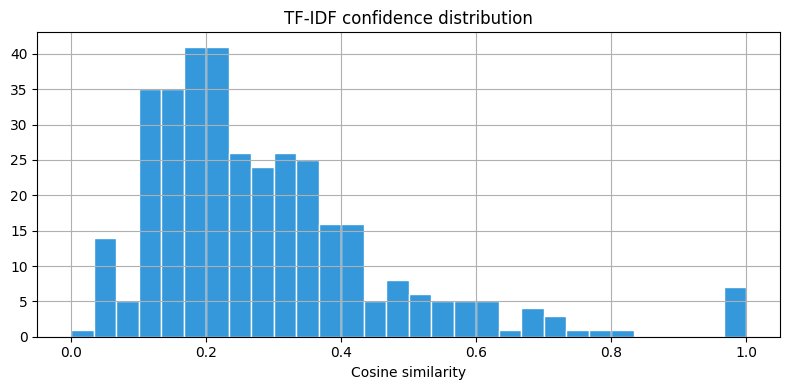

In [38]:
foundation_names = df_foundation["description"].tolist()
agri_names       = df_agri["lci_name"].tolist()

# Stage 1 — TF-IDF baseline
print("=== Stage 1: TF-IDF ===")
df_tfidf = tfidf_match(foundation_names, agri_names)
print(df_tfidf["score"].describe().round(3))
print()
print("15 example TF-IDF matches:")
print(df_tfidf.head(15).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
df_tfidf["score"].hist(bins=30, ax=ax, color="#3498db", edgecolor="white")
ax.set_title("TF-IDF confidence distribution")
ax.set_xlabel("Cosine similarity")
plt.tight_layout()
plt.show()


In [39]:
# Stage 2 — Bi-encoder only (top-1, no cross-encoder)
print("=== Stage 2: Bi-encoder top-1 ===")
bi, _ = _get_encoders()
src_emb = bi.encode(foundation_names, convert_to_tensor=True, show_progress_bar=True)
tgt_emb = bi.encode(agri_names,       convert_to_tensor=True, show_progress_bar=True)
bi_scores = util.cos_sim(src_emb, tgt_emb)

bi_rows = []
for i, src in enumerate(foundation_names):
    j = int(torch.argmax(bi_scores[i]))
    bi_rows.append({"source": src, "bi_match": agri_names[j],
                    "bi_conf": round(float(bi_scores[i][j]), 3)})
df_bi = pd.DataFrame(bi_rows)

print(df_bi["bi_conf"].describe().round(3))
changed_vs_tfidf = (df_bi["bi_match"] != df_tfidf["match"]).sum()
print(f"\nBi-encoder differs from TF-IDF: {changed_vs_tfidf}/{len(foundation_names)} "
      f"({changed_vs_tfidf/len(foundation_names)*100:.1f}%)")


=== Stage 2: Bi-encoder top-1 ===
Loading sentence transformers (first call only)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

count    357.000
mean       0.758
std        0.099
min        0.494
25%        0.687
50%        0.754
75%        0.826
max        1.000
Name: bi_conf, dtype: float64

Bi-encoder differs from TF-IDF: 242/357 (67.8%)


In [40]:
# Stage 3 — Bi + Cross re-ranking (FINAL)
print("=== Stage 3: Bi + Cross re-ranking (FINAL) ===")
df_co2_matched = match_with_reranking(
    source_names = foundation_names,
    target_names = agri_names,
    target_df    = df_agri,
    result_cols  = {"lci_name": "co2_match", "group": "co2_group", "co2_kg": "co2_kg"},
    label        = "CO2",
)
df_co2_matched.rename(columns={"source": "usda_description"}, inplace=True)

print(df_co2_matched["bi_encoder_conf"].describe().round(3))
changed_vs_bi = (df_co2_matched["co2_match"] != df_bi["bi_match"]).sum()
print(f"\nCross-encoder differs from bi top-1: {changed_vs_bi}/{len(foundation_names)} "
      f"({changed_vs_bi/len(foundation_names)*100:.1f}%)  — expected ~45%")


=== Stage 3: Bi + Cross re-ranking (FINAL) ===
[CO2] Encoding 357 source + 2454 target names...


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

[CO2] Cross-encoder re-ranking 3570 pairs...


Batches:   0%|          | 0/112 [00:00<?, ?it/s]

count    357.000
mean       0.727
std        0.115
min        0.452
25%        0.646
50%        0.713
75%        0.807
max        1.000
Name: bi_encoder_conf, dtype: float64

Cross-encoder differs from bi top-1: 204/357 (57.1%)  — expected ~45%


In [41]:
# Comparison table: 15 randomly selected products showing improvement across stages
sample_products = df_foundation["description"].sample(15, random_state=42).tolist()

rows_compare = []
for prod in sample_products:
    matches = [n for n in foundation_names if prod.lower() in n.lower()]
    if not matches:
        continue
    src = matches[0]
    tfidf_match_val = df_tfidf.loc[df_tfidf["source"] == src, "match"].values
    bi_match_val    = df_bi.loc[df_bi["source"] == src, "bi_match"].values
    cr_row          = df_co2_matched[df_co2_matched["usda_description"] == src]
    rows_compare.append({
        "usda_name":      src[:45],
        "tfidf":          tfidf_match_val[0][:35] if len(tfidf_match_val) else "—",
        "bi_only":        bi_match_val[0][:35]    if len(bi_match_val)    else "—",
        "cross_reranked": cr_row["co2_match"].values[0][:35] if len(cr_row) else "—",
        "bi_conf":        cr_row["bi_encoder_conf"].values[0]  if len(cr_row) else None,
        "cross_score":    cr_row["cross_encoder_score"].values[0] if len(cr_row) else None,
    })

df_compare = pd.DataFrame(rows_compare)
print("Matching evolution comparison (15 products):")
print(df_compare.to_string(index=False))


Matching evolution comparison (15 products):
                                    usda_name                              tfidf                             bi_only                      cross_reranked  bi_conf  cross_score
                            Mushroom, maitake          Mushroom sauce, prepacked            Omelette, with mushrooms           Mushroom sauce, prepacked    0.546        0.656
Beans, snap, green, canned, regular pack, dra       Beer, regular (4-5° alcohol)     Beans, mung, mature, seeds, dry Mung bean, sprouted or soy spouts,     0.664        0.671
             Potatoes, red, without skin, raw Chicken, breast, without skin, raw                 Potato, peeled, raw                     New potato, raw    0.708        0.632
                 Rice, black, unenriched, raw                          Rice, raw                    Rice, brown, raw                           Rice, raw    0.813        0.741
Beef, short loin, t-bone steak, bone-in, sepa              Beef, short ribs, raw

## 6. CO2 Corrections (Three Layers)

In [42]:
# Apply hybrid quality flag before running corrections
# (match_with_reranking doesn't set match_quality; we derive it here)
df_co2_matched["match_quality"] = np.where(
    (df_co2_matched["cross_encoder_score"] >= 0) & (df_co2_matched["bi_encoder_conf"] >= 0.60),
    "high",
    np.where(df_co2_matched["bi_encoder_conf"] >= 0.75, "medium", "low"),
)

df_co2_corrected, group_means = apply_co2_corrections(
    df_matched            = df_co2_matched,
    df_agri               = df_agri,
    group_labels          = AGRIBALYSE_GROUP_LABELS,
    overrides             = CO2_PRODUCT_OVERRIDES,
    suspicious_threshold  = CO2_SUSPICIOUS_THRESHOLD,
)

# Post-correction targeted fixes
fixes = {
    "mushroom":    ("fruits_veg_legumes", group_means.get("fruits_veg_legumes", 1.484)),
    "lobster, tail": ("meat_fish_eggs",  group_means.get("meat_fish_eggs", 13.037)),
}
for keyword, (group_label, co2_val) in fixes.items():
    mask = df_co2_corrected["usda_description"].str.lower().str.contains(keyword, na=False)
    df_co2_corrected.loc[mask, "co2_kg_final"]     = co2_val
    df_co2_corrected.loc[mask, "correction_layer"] = f"layer1_fix_{group_label}"
    print(f"Post-fix: {mask.sum()} rows for '{keyword}' → {co2_val:.3f} kg CO2/kg")

print("\nCorrection layer distribution:")
print(df_co2_corrected["correction_layer"].value_counts())
print("\nFinal CO2 range:")
print(df_co2_corrected["co2_kg_final"].describe().round(3))


Post-fix: 11 rows for 'mushroom' → 1.484 kg CO2/kg
Post-fix: 1 rows for 'lobster, tail' → 13.037 kg CO2/kg

Correction layer distribution:
correction_layer
layer3_kept                      320
layer1_product                    21
layer1_fix_fruits_veg_legumes     11
layer1_not_found                   3
layer1_fix_meat_fish_eggs          1
layer1_group_fallback              1
Name: count, dtype: int64

Final CO2 range:
count    357.000
mean       3.956
std        6.707
min        0.334
25%        0.825
50%        1.484
75%        4.110
max       36.600
Name: co2_kg_final, dtype: float64



── layer3_kept (320 rows) ──
                                                 usda_description                                                                                                                                              co2_match  co2_kg  co2_kg_final
                                            Almond butter, creamy                                                                                                                                    Sugar-coated almond   1.770         1.770
               Anchovies, canned in olive oil, with salt, drained                                                                                                                      Anchovy, in salt (semi-preserved)   2.600         2.600
Apple juice, with added vitamin C, from concentrate, shelf stable                                                                                                                                Apple juice, pure juice   0.567         0.567
              

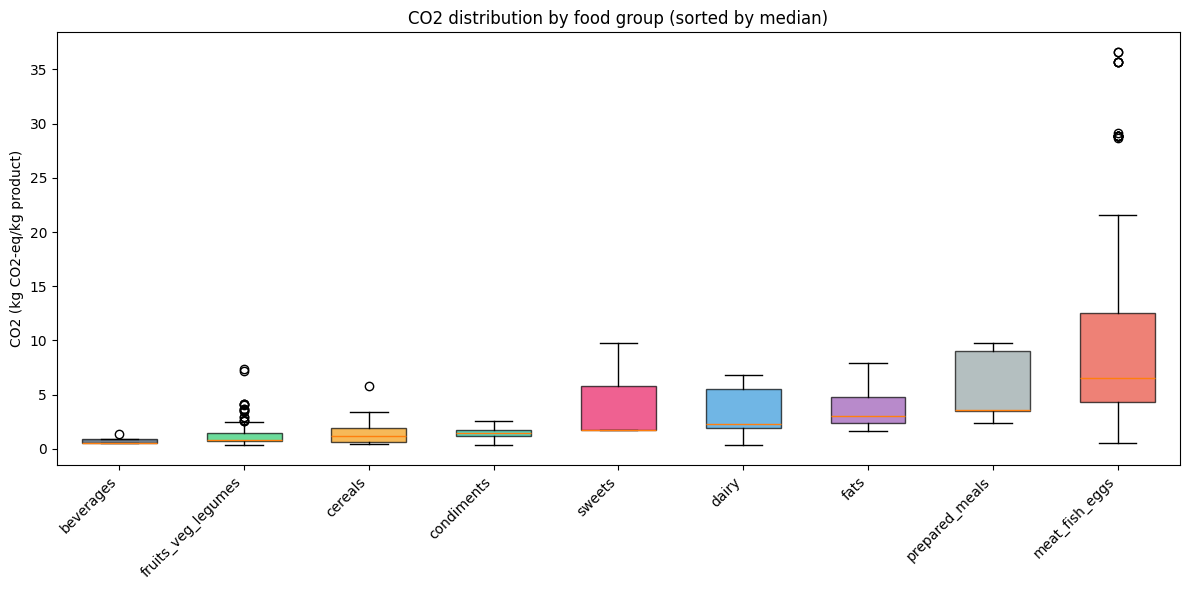

In [43]:
# Correction examples — 10 rows each layer
for layer in df_co2_corrected["correction_layer"].unique():
    subset = df_co2_corrected[df_co2_corrected["correction_layer"] == layer]
    print(f"\n── {layer} ({len(subset)} rows) ──")
    print(subset[["usda_description", "co2_match", "co2_kg", "co2_kg_final"]]
          .drop_duplicates("usda_description").head(10).to_string(index=False))

# CO2 distribution by food group
df_plot = df_co2_corrected.copy()
df_plot["group_en"] = df_plot["co2_group"].map(AGRIBALYSE_GROUP_LABELS).fillna("other")
group_order = (df_plot.groupby("group_en")["co2_kg_final"]
               .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
for i, grp in enumerate(group_order):
    vals = df_plot.loc[df_plot["group_en"] == grp, "co2_kg_final"].dropna()
    ax.boxplot(vals, positions=[i], widths=0.6,
               patch_artist=True,
               boxprops=dict(facecolor=PALETTE.get(grp, PALETTE["default"]), alpha=0.7))
ax.set_xticks(range(len(group_order)))
ax.set_xticklabels(group_order, rotation=45, ha="right")
ax.set_ylabel("CO2 (kg CO2-eq/kg product)")
ax.set_title("CO2 distribution by food group (sorted by median)")
plt.tight_layout()
plt.show()


## 7. Price Matching (USDA → FMAP)

FMAP has only 90 broad categories (vs 369 USDA products), so price is approximate
by design. bi_encoder_conf is typically lower here (~0.60 mean) — this is expected.
Price is a group-level approximation, not a product-level measurement.


[Price] Encoding 357 source + 90 target names...


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

[Price] Cross-encoder re-ranking 3570 pairs...


Batches:   0%|          | 0/112 [00:00<?, ?it/s]

Price bi_encoder_conf distribution:
count    357.000
mean       0.564
std        0.106
min        0.264
25%        0.502
50%        0.560
75%        0.644
max        0.874
Name: bi_encoder_conf, dtype: float64


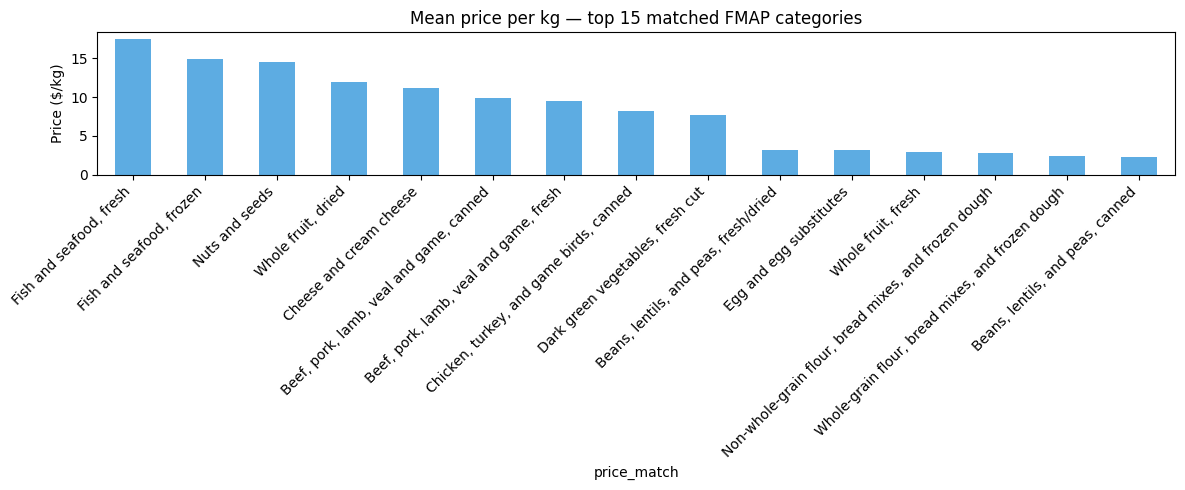

In [44]:
df_price_matched = match_with_reranking(
    source_names = foundation_names,
    target_names = df_prices["efpg_name"].tolist(),
    target_df    = df_prices,
    result_cols  = {"efpg_name": "price_match", "price_per_kg": "price_per_kg"},
    label        = "Price",
)
df_price_matched.rename(columns={"source": "usda_description"}, inplace=True)

print("Price bi_encoder_conf distribution:")
print(df_price_matched["bi_encoder_conf"].describe().round(3))

# Distribution by top-15 matched categories
top_cats = df_price_matched["price_match"].value_counts().head(15).index
df_price_top = df_price_matched[df_price_matched["price_match"].isin(top_cats)]

fig, ax = plt.subplots(figsize=(12, 5))
(df_price_top.groupby("price_match")["price_per_kg"]
 .mean().sort_values(ascending=False)
 .plot(kind="bar", ax=ax, color="#3498db", alpha=0.8))
ax.set_ylabel("Price ($/kg)")
ax.set_title("Mean price per kg — top 15 matched FMAP categories")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8. Final Assembly

In [45]:
# Deduplicate matching results on usda_description (should already be unique)
df_co2_final   = df_co2_corrected.drop_duplicates("usda_description")
df_price_final = df_price_matched.drop_duplicates("usda_description")

# Merge foundation + CO2 + price
df_final = (
    df_foundation
    .merge(df_co2_final[["usda_description", "co2_match", "co2_group",
                          "co2_kg", "co2_kg_final", "correction_layer",
                          "bi_encoder_conf", "cross_encoder_score"]],
           left_on="description", right_on="usda_description", how="left")
    .drop(columns="usda_description", errors="ignore")
    .merge(df_price_final[["usda_description", "price_match", "price_per_kg"]],
           left_on="description", right_on="usda_description", how="left")
    .drop(columns="usda_description", errors="ignore")
)

print("Merged shape:", df_final.shape)

# NaN audit on objective columns
obj_cols = ["co2_kg_final", "price_per_kg", "Protein_per_100kcal"]
print("\nNaN counts per objective column:")
for c in obj_cols:
    if c in df_final.columns:
        print(f"  {c}: {df_final[c].isna().sum()}")


Merged shape: (357, 32)

NaN counts per objective column:
  co2_kg_final: 0
  price_per_kg: 0
  Protein_per_100kcal: 0


In [46]:
# Drop rows missing any objective
df_analysis = df_final.dropna(subset=[c for c in obj_cols if c in df_final.columns]).copy()

assert len(df_analysis) >= 350, f"Expected >= 350 rows, got {len(df_analysis)}"

print(f"Final shape: {df_analysis.shape}")
print("\nObjective ranges:")
for c in obj_cols:
    if c in df_analysis.columns:
        print(f"  {c}: [{df_analysis[c].min():.2f}, {df_analysis[c].max():.2f}]")

print("\nSample rows:")
df_analysis[["description", "co2_kg_final", "price_per_kg", "Protein_per_100kcal",
              "co2_group", "correction_layer"]].head(5)


Final shape: (357, 32)

Objective ranges:
  co2_kg_final: [0.33, 36.60]
  price_per_kg: [1.07, 17.46]
  Protein_per_100kcal: [0.00, 24.25]

Sample rows:


,description,co2_kg_final,price_per_kg,Protein_per_100kcal,co2_group,correction_layer
0,"Almond butter, creamy",1.770,5.743056,3.220567,produits sucrés,layer3_kept
1,"Almond milk, unsweetened, plain, refrigerated",0.381,2.691667,3.394982,lait et produits laitiers,layer1_product
2,"Almond milk, unsweetened, plain, shelf stable",0.381,2.691667,3.810661,lait et produits laitiers,layer1_product
3,"Anchovies, canned in olive oil, with salt, dra...",2.600,3.967500,13.072332,"viandes, œufs, poissons",layer3_kept
4,"Apple juice, with added vitamin C, from concen...",0.567,1.983611,0.177644,boissons,layer3_kept


In [47]:
# Verification: raw corrections for vegetables and oils were applied earlier in
# Section 4, directly on df_wide before normalize_to_density().  All _per_100kcal
# columns therefore already reflect the corrected values — no patch needed here.
# This block just confirms the final values are sane.
check_cols = ["description", "Energy [kcal]",
              "Carbohydrate_by_difference_per_100kcal", "Protein_per_100kcal",
              "Total_lipid_(fat)_per_100kcal", "Fiber_total_dietary_per_100kcal"]

mask_veg = df_analysis["description"].str.contains(
    "Shallots, bulb, peeled|Leeks, bulb and greens|Blackberries, raw", case=False, na=False)
print("Corrected vegetables — final values in df_analysis:")
print(df_analysis[mask_veg][check_cols].to_string(index=False))

mask_oil = df_analysis["description"].str.lower().str.startswith("oil,")
print(f"\nOils ({mask_oil.sum()} rows) — fat density should be ~11.3 g/100 kcal:")
print(df_analysis[mask_oil][check_cols].to_string(index=False))

Corrected vegetables — final values in df_analysis:
                              description  Energy [kcal]  Carbohydrate_by_difference_per_100kcal  Protein_per_100kcal  Total_lipid_(fat)_per_100kcal  Fiber_total_dietary_per_100kcal
                        Blackberries, raw           42.3                               16.548463             4.728132                       1.654846                        12.529551
Leeks, bulb and greens, root removed, raw           24.3                               16.049383             6.172840                       1.234568                         7.407407
Shallots, bulb, peeled, root removed, raw           66.9                               20.926756             3.736921                       0.149477                         4.783259

Oils (9 rows) — fat density should be ~11.3 g/100 kcal:
             description  Energy [kcal]  Carbohydrate_by_difference_per_100kcal  Protein_per_100kcal  Total_lipid_(fat)_per_100kcal  Fiber_total_dietary_per_100kca

In [48]:
#morover, some of chesses are counted as milk for price in FMAP which is not ideal;
# let's manually set everything starting with 'Cheese' to have a price of 12.5 $/kg, 
# which is a reasonable average price for cheese, 
# and recalculate price_per_100g for these products and print them out to check
cheese_mask = df_analysis["description"].str.startswith("Cheese", na=False)
df_analysis.loc[cheese_mask, "price_per_kg"] = 12.5
print("\nCheese products with updated price:")
print(df_analysis[cheese_mask][["description", "price_per_kg"]].to_string(index=False))


Cheese products with updated price:
                                                          description  price_per_kg
                                         Cheese, American, restaurant          12.5
                                                      Cheese, cheddar          12.5
                                                Cheese, cotija, solid          12.5
                                  Cheese, cottage, lowfat, 2% milkfat          12.5
                                        Cheese, dry white, queso seco          12.5
                                   Cheese, feta, whole milk, crumbled          12.5
                                         Cheese, monterey jack, solid          12.5
                          Cheese, mozzarella, low moisture, part-skim          12.5
                                                Cheese, oaxaca, solid          12.5
                                             Cheese, parmesan, grated          12.5
                               Cheese, 

In [49]:
df_analysis.to_csv("foundation_analysis_ready.csv", index=False)
print("Saved: foundation_analysis_ready.csv")


Saved: foundation_analysis_ready.csv
